# 2025-07-26: Annotate the outliers only [Stochastic]
### By [Aishwarya Chander](aishwarya.chander@alleninstitute.org), High Resolution Translational Immunology, Allen Institute for Immunology
**Main Aim**: This notebook identifies cells that were not assigned a cell type label during the initial annotation pass. These unlabelled cells are isolated, reclustered, and assessed for quality — filtering out high mitochondrial content, high doublet scores, and junk clusters. The remaining cells are grouped into broad lineage categories (T-like, B-like, monocyte, progenitor, progenitor-erythroid) and individually reprocessed with Harmony to recover usable cells that were missed in earlier annotation steps.

## 1. Imports

In [1]:
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import os
import glob
import anndata as ad
import numpy as np
import pandas as pd
import scanpy.external as sce

sc.settings.n_jobs = 30
sc.settings.verbosity = 0

plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (5, 5)

In [2]:
import sys
sys.path.insert(0, '../../00-utilities/functions/python/')
from process_scrna_data import process_adata

## 2. Process object

In [3]:
adata = sc.read_h5ad('../../../data/rna/bmmc/all-bmmc-processed.h5ad')

In [4]:
# Load plasma metadata and rename column
plasma_cells = pd.read_parquet('../../../data/rna/plasma/all-plasma-metadata.parquet')
plasma_cells.rename(columns={"cell_states": "aifi_celltype_l3"}, inplace=True)
plasma_subset = plasma_cells[['cell_uuid', 'aifi_celltype_l3']]

# Load and concatenate all parquet files in the BMMC labels folder
folder_path = "../../../data/rna/bmmc-labels/"
parquet_files = glob.glob(os.path.join(folder_path, "*.parquet"))
bmmc_labels_df = pd.concat([pd.read_parquet(f) for f in parquet_files], ignore_index=True)

# Combine BMMC labels with plasma metadata
df_all = pd.concat([bmmc_labels_df, plasma_subset], ignore_index=True)

In [6]:
df_all.set_index("cell_uuid", inplace=True)
df_all.index.name = "barcodes"

In [7]:
adata.obs = adata.obs.merge(df_all, on='barcodes', how='left')

In [12]:
adata = adata[adata.obs['aifi_celltype_l3'].isna()]
adata = process_adata(adata, resolution=2, run_harmony=False)

adata.obs = adata.obs.drop(['aifi_celltype_l3'], axis=1)

## 3. Processing Outliers

In [100]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

In [101]:
adata.obs['high_mt'] = adata.obs['pct_counts_mt'] >= 3
adata.obs['high_doublet'] = adata.obs['doublet_score'] >= 0.35

clusters = ['1', '18', '21', '23', '26', '30', '40', '41', '43', '44', '48']
adata.obs['junk'] = False
adata.obs.loc[adata.obs['leiden'].isin(clusters), 'junk'] = True

In [109]:
clean_subset = adata[~adata.obs['high_mt'] & ~adata.obs['high_doublet'] & ~adata.obs['junk']]

## 4. Subset outliers to meaningful groups

In [104]:
# Clusters to relabel
leiden_to_label = {
    '0': 'T-like',
    '2': 'T-like',
    '3': 'T-like',
    '4': 'T-like',
    '5': 'T-like',
    '6': 'T-like',
    '7': 'T-like',
    '8': 'T-like',
    '9': 'T-like',
    '10': 'T-like',
    '11': 'T-like',
    '12': 'Progenitor-Ery',
    '13': 'T-like',
    '14': 'Progenitor',
    '15': 'Progenitor',
    '16': 'T-like',
    '17': 'Progenitor-Ery',
    '19': 'Progenitor-Ery',
    '20': 'Progenitor-Ery',
    '22': 'Monocyte',
    '24': 'T-like',
    '25': 'T-like',
    '27': 'Monocyte',
    '28': 'Monocyte',
    '29': 'T-like',
    '31': 'Progenitor-Ery',
    '32': 'T-like',
    '33': 'T-like',
    '34': 'B-like',
    '35': 'B-like',
    '36': 'Progenitor-Ery',
    '37': 'Progenitor-Ery',
    '38': 'Progenitor',
    '39': 'Progenitor',
    '42': 'T-like',
    '45': 'B-like',
    '46': 'B-like',
    '47': 'B-like',
    '49': 'T-like',
    '50': 'B-like'
}

clean_subset.obs['group_labels'] = clean_subset.obs['leiden'].map(leiden_to_label).astype('category').cat.remove_unused_categories()

/tmp/ipykernel_26982/2971348472.py:43: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  clean_subset.obs['group_labels'] = clean_subset.obs['leiden'].map(leiden_to_label).astype('category').cat.remove_unused_categories()


In [106]:
mask = ~(
    (clean_subset.obs['group_labels'] != 'Progenitor-Ery') &
    (
        (clean_subset.obs['healthy_l2'].isin(['prog_late_ery', 'prog_early_ery'])) |
        (clean_subset.obs['ext_l3'] == 'RBC')
    )
)

clean_subset = clean_subset[mask]

## 5. View clean outliers

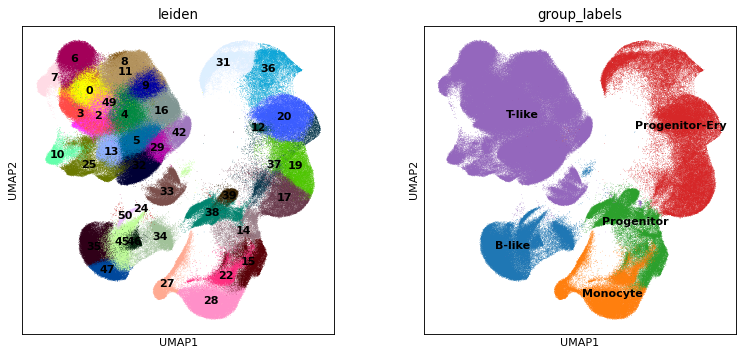

In [110]:
sc.pl.umap(clean_subset, color=['leiden', 'group_labels'], legend_loc='on data', size=1)

In [121]:
clean_subset.write('../../../data/rna/bmmc-outliers/clean_subset.h5ad')

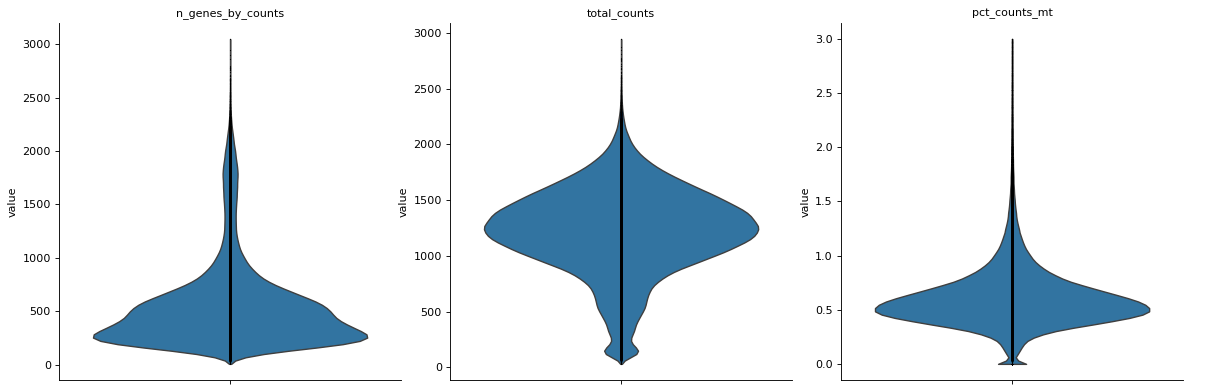

In [7]:
sc.pl.violin(
    clean_subset, 
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    multi_panel = True, jitter=False
)

In [ ]:
clusters = list(clean_subset.obs['group_labels'].value_counts().index)
clusters.reverse()

for cluster in clusters:
    print(f'Processing {cluster}')
    subset = clean_subset[clean_subset.obs['group_labels'] == cluster]
    subset = process_adata(subset, resolution=1.5, run_harmony=True)
    subset.write(f'../../../data/rna/bmmc-outliers/outlier-{cluster}.h5ad')

Processing Progenitor


2025-08-04 14:55:47,192 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-04 14:55:48,766 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-04 14:55:49,189 - harmonypy - INFO - Iteration 1 of 10
2025-08-04 14:55:58,093 - harmonypy - INFO - Iteration 2 of 10
2025-08-04 14:56:08,676 - harmonypy - INFO - Iteration 3 of 10
2025-08-04 14:56:17,976 - harmonypy - INFO - Iteration 4 of 10
2025-08-04 14:56:25,416 - harmonypy - INFO - Iteration 5 of 10
2025-08-04 14:56:30,666 - harmonypy - INFO - Iteration 6 of 10
2025-08-04 14:56:35,887 - harmonypy - INFO - Iteration 7 of 10
2025-08-04 14:56:41,169 - harmonypy - INFO - Iteration 8 of 10
2025-08-04 14:56:46,166 - harmonypy - INFO - Iteration 9 of 10
2025-08-04 14:56:50,850 - harmonypy - INFO - Iteration 10 of 10
2025-08-04 14:56:56,264 - harmonypy - INFO - Converged after 10 iterations
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In pr

Processing Monocyte


2025-08-04 14:59:56,275 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-04 14:59:57,854 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-04 14:59:58,489 - harmonypy - INFO - Iteration 1 of 10
2025-08-04 15:00:07,811 - harmonypy - INFO - Iteration 2 of 10
2025-08-04 15:00:18,049 - harmonypy - INFO - Iteration 3 of 10
2025-08-04 15:00:27,732 - harmonypy - INFO - Iteration 4 of 10
2025-08-04 15:00:37,247 - harmonypy - INFO - Converged after 4 iterations
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you'd like the old behaviour (which is deprecated), pass 'use_fast_tsne=True'. Note, MulticoreTSNE is not actually faster anymore.
  warnings.warn(


Processing B-like


2025-08-04 15:03:00,483 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-04 15:03:02,530 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-04 15:03:03,094 - harmonypy - INFO - Iteration 1 of 10
2025-08-04 15:03:19,271 - harmonypy - INFO - Iteration 2 of 10
2025-08-04 15:03:35,364 - harmonypy - INFO - Iteration 3 of 10
2025-08-04 15:03:52,709 - harmonypy - INFO - Iteration 4 of 10
2025-08-04 15:04:08,653 - harmonypy - INFO - Iteration 5 of 10
2025-08-04 15:04:23,104 - harmonypy - INFO - Iteration 6 of 10
2025-08-04 15:04:32,159 - harmonypy - INFO - Iteration 7 of 10
2025-08-04 15:04:39,689 - harmonypy - INFO - Iteration 8 of 10
2025-08-04 15:04:46,391 - harmonypy - INFO - Iteration 9 of 10
2025-08-04 15:04:53,190 - harmonypy - INFO - Converged after 9 iterations
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use

Processing Progenitor-Ery


2025-08-04 15:08:36,277 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-04 15:08:39,152 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-04 15:08:39,426 - harmonypy - INFO - Iteration 1 of 10
2025-08-04 15:09:07,031 - harmonypy - INFO - Iteration 2 of 10
2025-08-04 15:09:34,038 - harmonypy - INFO - Iteration 3 of 10
2025-08-04 15:10:01,317 - harmonypy - INFO - Iteration 4 of 10
2025-08-04 15:10:26,475 - harmonypy - INFO - Iteration 5 of 10
2025-08-04 15:10:53,343 - harmonypy - INFO - Iteration 6 of 10
2025-08-04 15:11:19,363 - harmonypy - INFO - Iteration 7 of 10
2025-08-04 15:11:46,110 - harmonypy - INFO - Iteration 8 of 10
2025-08-04 15:12:13,029 - harmonypy - INFO - Iteration 9 of 10
2025-08-04 15:12:37,930 - harmonypy - INFO - Iteration 10 of 10
2025-08-04 15:13:03,849 - harmonypy - INFO - Stopped before convergence
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previ